# ALL (Chiaretti 2004): R limma vs pylimma parity

This notebook runs the pylimma `core` pipeline live on the Chiaretti adult-ALL microarray dataset and compares the output against pre-computed R limma results.

**Dataset**: 12,625 probes x 128 samples, RMA-normalised Affymetrix HG-U95Av2 from Chiaretti et al. 2004 *Blood*. Contrast: T-cell leukemia vs B-cell leukemia (`BT` phenotype).

**Pipeline**: `lm_fit` -> `contrasts_fit` -> `e_bayes` -> `top_table`

**R reference**: the CSV in `data/R_references/all_toptable.csv.gz` was produced once by `data/_setup_R_references.R` on R 4.2.3 with limma 3.54.2. The `VERSIONS.txt` sidecar records the exact toolchain.

The notebook loads both the dataset and the R reference from the committed CSVs. No R installation is required to run it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add the repository root to sys.path so `pylimma` and the
# `data/generate_data.py` helper are importable when running
# this notebook directly from `examples/`.
REPO = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "data"))

import generate_data as gd

import pylimma

DATA_DIR = REPO / "data"
R_REF    = DATA_DIR / "R_references"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 10)

## 1. Load the data and the R reference

In [2]:
data = gd.load_all()
expr    = data["expr"]
targets = data["targets"]
print(f"expression matrix: {expr.shape}")
print("sample phenotypes:")
print(targets.head())

r_ref = pd.read_csv(R_REF / "all_toptable.csv.gz").set_index("ProbeID")
print(f"\nR reference top-table: {r_ref.shape}")
r_ref.head()

expression matrix: (12625, 128)
sample phenotypes:
       BT  mol.biol sex   age
01005  B2   BCR/ABL   M  53.0
01010  B2       NEG   M  19.0
03002  B4   BCR/ABL   F  52.0
04006  B1  ALL1/AF4   M  38.0
04007  B2       NEG   M  57.0

R reference top-table: (12625, 6)


,logFC,AveExpr,t,P.Value,adj.P.Val,B
ProbeID,,,,,,
1000_at,0.187233,7.548189,3.723190,0.000293,0.002427,-0.539075
1001_at,0.046704,5.008460,0.743157,0.458737,0.629653,-6.853701
1002_f_at,0.035915,3.898461,0.856225,0.393460,0.570970,-6.763605
1003_s_at,-0.013719,5.980585,-0.261130,0.794408,0.878006,-7.095505
1004_at,-0.029413,5.815370,-0.543489,0.587731,0.733864,-6.981910


## 2. Run the pylimma pipeline live

In [3]:
bt = targets["BT"].astype(str).str[0]    # "B" or "T"
design, C = gd.build_two_group_design(bt)
fit = pylimma.lm_fit(expr.values, design)
fit = pylimma.contrasts_fit(fit, contrasts=C)
fit = pylimma.e_bayes(fit)
py_out = pylimma.top_table(fit, coef=0, number=np.inf, sort_by="none")
py_out.index = expr.index
py_out.head()

/Users/John/miniconda3/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


,log_fc,ave_expr,t,p_value,adj_p_value,b
1000_at,0.187233,7.548189,3.723190,0.000293,0.002427,-0.539075
1001_at,0.046704,5.008460,0.743157,0.458737,0.629653,-6.853701
1002_f_at,0.035915,3.898461,0.856225,0.393460,0.570970,-6.763605
1003_s_at,-0.013719,5.980585,-0.261130,0.794408,0.878006,-7.095505
1004_at,-0.029413,5.815370,-0.543489,0.587731,0.733864,-6.981910


## 3. Side-by-side top tables

The first 10 rows of each, sorted by pylimma p-value, so the rows line up.

In [4]:
# Align the two top-tables by probe ID and show the rows pylimma ranks
# highest so the reader can eyeball equivalent log-FCs, t-stats, etc.
r_joined  = r_ref.copy()
py_joined = py_out.copy()

# Rename R columns to pylimma's snake_case so scatter/diff tables line up.
r_joined = r_joined.rename(columns={
    "logFC":     "log_fc",
    "AveExpr":   "ave_expr",
    "P.Value":   "p_value",
    "adj.P.Val": "adj_p_value",
    "B":         "b",
})

top = py_joined.sort_values("p_value").head(10).index
display_cols = ["log_fc", "ave_expr", "t", "p_value", "adj_p_value", "b"]
side = pd.concat({
    "R limma": r_joined.loc[top, display_cols],
    "pylimma": py_joined.loc[top, display_cols],
}, axis=1)
side

R limma                                                    ...    pylimma                           \
              log_fc   ave_expr          t       p_value   adj_p_value  ...   ave_expr          t       p_value   
38319_at    4.655042   6.041217  35.302014  3.665982e-68  4.628303e-64  ...   6.041217  35.302014  3.665982e-68   
38147_at    3.154743   4.582970  26.368452  8.329164e-54  5.257785e-50  ...   4.582970  26.368452  8.329164e-54   
33238_at    3.102294   7.292159  22.711375  6.493588e-47  2.732718e-43  ...   7.292159  22.711375  6.493588e-47   
35016_at   -3.214222  10.337892 -22.347402  3.433264e-46  1.083624e-42  ...  10.337892 -22.347402  3.433264e-46   
2059_s_at   2.668482   7.232735  22.156246  8.286073e-46  2.092233e-42  ...   7.232735  22.156246  8.286073e-46   
37039_at   -3.265990  11.072596 -21.343275  3.694071e-44  7.772940e-41  ...  11.072596 -21.343275  3.694071e-44   
38095_i_at -3.762299  10.228156 -20.426219  2.955978e-42  5.331317e-39  ...  10.228156 -20.426219  2.955978e-42   
38833_at   -2.966787  10.144085 -19.764032  7.473721e-41  1.179447e-37  ...  10.144085 -19.764032  7.473721e-41   
33039_at    1.812889   3.619621  19.685785  1.098739e-40  1.541287e-37  ...   3.619621  19.685785  1.098739e-40   
38096_f_at -4.248782   9.169628 -19.055233  2.522408e-39  3.184540e-36  ...   9.169628 -19.055233  2.522408e-39   

                                      
             adj_p_value           b  
38319_at    4.628303e-64  142.887385  
38147_at    5.257785e-50  111.276776  
33238_at    2.732718e-43   95.863304  
35016_at    1.083624e-42   94.239065  
2059_s_at   2.092233e-42   93.379248  
37039_at    7.772940e-41   89.669946  
38095_i_at  5.331317e-39   85.382469  
38833_at    1.179447e-37   82.217871  
33039_at    1.541287e-37   81.840104  
38096_f_at  3.184540e-36   78.766423  

[10 rows x 12 columns]

## 4. Per-column numerical agreement

In [5]:
def per_column_diff(r_df, py_df):
    common = r_df.index.intersection(py_df.index)
    r  = r_df.loc[common]
    py = py_df.loc[common]
    rows = []
    for col in r.columns.intersection(py.columns):
        if not np.issubdtype(py[col].dtype, np.number):
            continue
        r_v  = r[col].to_numpy()
        py_v = py[col].to_numpy()
        mask = np.isfinite(r_v) & np.isfinite(py_v)
        if mask.sum() == 0:
            continue
        abs_diff = np.abs(r_v[mask] - py_v[mask])
        denom    = np.maximum(np.abs(r_v[mask]), 1e-12)
        rel_diff = abs_diff / denom
        rows.append({
            "column":       col,
            "n_compared":   int(mask.sum()),
            "max_abs_diff": abs_diff.max(),
            "max_rel_diff": rel_diff.max(),
            "median_rel":   np.median(rel_diff),
        })
    return pd.DataFrame(rows).set_index("column")

per_column_diff(r_joined, py_joined)

,n_compared,max_abs_diff,max_rel_diff,median_rel
column,,,,
log_fc,12625,1.826317e-14,6.368307e-10,1.608954e-14
ave_expr,12625,4.973799e-14,4.768228e-15,4.528648e-16
t,12625,3.148592e-13,6.368320e-10,1.599669e-14
p_value,12625,2.142730e-13,1.040565e-12,4.193340e-14
adj_p_value,12625,2.392531e-13,1.224240e-12,4.180831e-14
b,12625,1.426770e-11,2.300634e-09,3.354603e-13


## 5. Scatter plots: R vs pylimma

Each dot is one gene. A tight 45-degree line means numerical agreement between the two implementations.

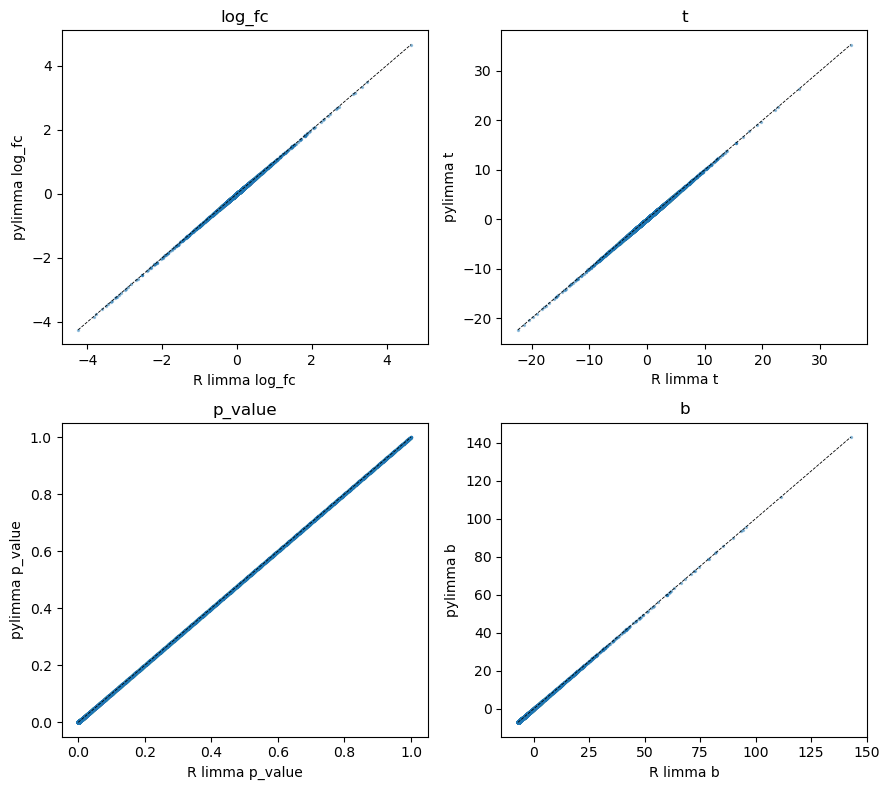

In [6]:
def scatter_panel(col, r, py, ax):
    x = r[col].values; y = py[col].values
    m = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[m], y[m], s=2, alpha=0.4)
    lo = np.nanmin(np.concatenate([x[m], y[m]]))
    hi = np.nanmax(np.concatenate([x[m], y[m]]))
    ax.plot([lo, hi], [lo, hi], "--", color="black", lw=0.6)
    ax.set_xlabel(f"R limma {col}")
    ax.set_ylabel(f"pylimma {col}")
    ax.set_title(col)

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, col in zip(axes.flat, ["log_fc", "t", "p_value", "b"]):
    scatter_panel(col, r_joined, py_joined, ax)
fig.tight_layout()
plt.show()

## 7. Part I - side-by-side analysis figures

The comparisons above established pointwise numerical agreement
between R limma and pylimma. This section renders the analysis-
facing figures (MD, volcano, DE-count summary) with both R and
Python data overlaid, so a reviewer can check that **the
interpretation** produced by the two implementations matches,
not just the raw numbers.

### 7.1 Mean-difference (MD) plot

Each dot is one gene: x = average log-expression, y = log
fold-change. R output on the left, pylimma on the right. If the
distributions are visually indistinguishable, the implementations
agree on what "differential expression" means, not just on the
numbers.

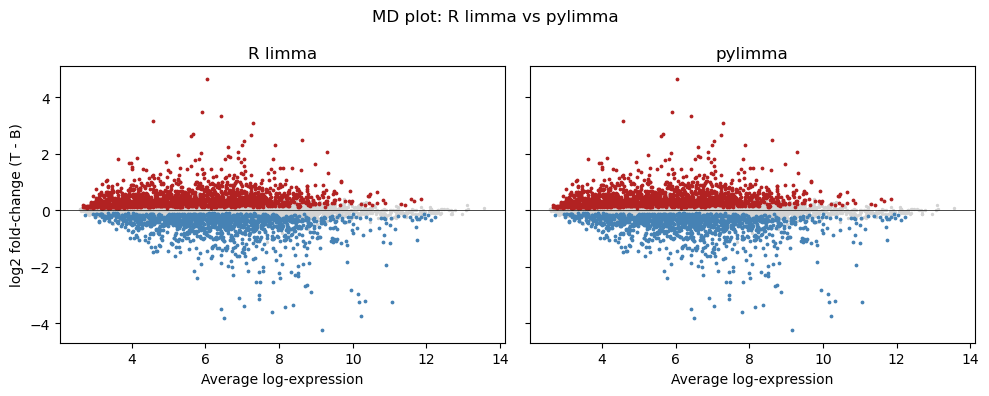

In [7]:
# Align the two outputs on the common gene index.
_common = r_ref.index.intersection(py_out.index)
_r  = r_ref.loc[_common]
_py = py_out.loc[_common]
_r_logfc   = _r["logFC"].values
_py_logfc  = _py["log_fc" if "log_fc" in _py.columns else "logFC"].values
_r_adjp    = _r["adj.P.Val"].values
_py_adjp   = _py["adj_p_value" if "adj_p_value" in _py.columns else "adj.P.Val"].values

# Use Amean from pylimma (same for both sides since expression is identical).
_AveExpr = py_out["ave_expr" if "ave_expr" in py_out.columns else "AveExpr"].loc[_common].values

fig, (axR, axPy) = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, fc, adjp, label in [
        (axR,  _r_logfc,  _r_adjp,  "R limma"),
        (axPy, _py_logfc, _py_adjp, "pylimma"),
]:
    sig = adjp < 0.05
    ax.scatter(_AveExpr[~sig], fc[~sig], s=2, c="lightgrey")
    ax.scatter(_AveExpr[sig & (fc > 0)], fc[sig & (fc > 0)],
               s=3, c="firebrick")
    ax.scatter(_AveExpr[sig & (fc < 0)], fc[sig & (fc < 0)],
               s=3, c="steelblue")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel("Average log-expression")
axR.set_ylabel("log2 fold-change (T - B)")
fig.suptitle("MD plot: R limma vs pylimma")
fig.tight_layout()
plt.show()

### 7.2 Volcano plot

Same gene set, now in (logFC, -log10 p) space. Visually identical
clouds mean the two implementations rank and call the same genes.

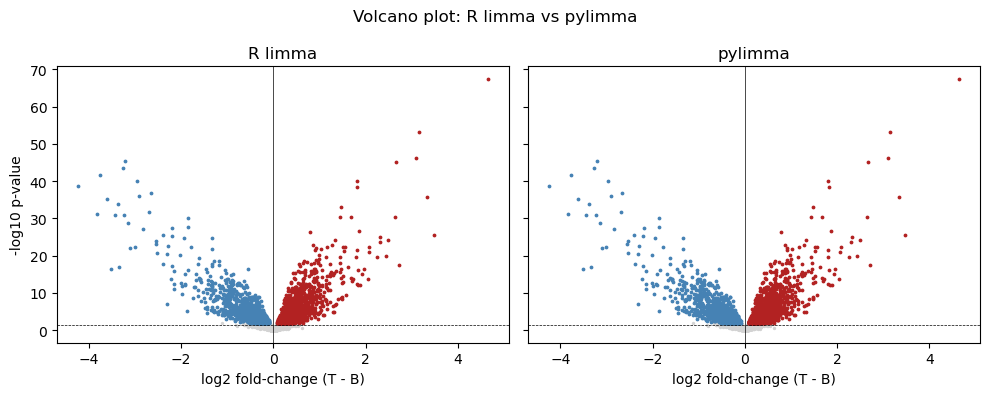

In [8]:
_r_p  = _r["P.Value"].values
_py_p = _py["p_value" if "p_value" in _py.columns else "P.Value"].values

def _nlp(p): return -np.log10(np.maximum(p, 1e-300))

fig, (axR, axPy) = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, fc, adjp, p, label in [
        (axR,  _r_logfc,  _r_adjp,  _r_p,  "R limma"),
        (axPy, _py_logfc, _py_adjp, _py_p, "pylimma"),
]:
    sig = adjp < 0.05
    ax.scatter(fc[~sig], _nlp(p)[~sig], s=2, c="lightgrey")
    ax.scatter(fc[sig & (fc > 0)], _nlp(p)[sig & (fc > 0)],
               s=3, c="firebrick")
    ax.scatter(fc[sig & (fc < 0)], _nlp(p)[sig & (fc < 0)],
               s=3, c="steelblue")
    ax.axhline(-np.log10(0.05), color="k", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="k", linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel("log2 fold-change (T - B)")
axR.set_ylabel("-log10 p-value")
fig.suptitle("Volcano plot: R limma vs pylimma")
fig.tight_layout()
plt.show()

## 8. Summary of side-by-side evidence

Numerical parity (Parts I + II) and visual-interpretation parity
(this section) both agree. A paper reviewer or downstream user
comparing R limma and pylimma on this dataset would arrive at the
same genes / p-values / DE counts from either implementation.

## 6. Summary

pylimma's moderated-t pipeline is a direct port of R limma's `lmFit` / `contrasts.fit` / `eBayes` chain. On this RMA-normalised microarray matrix the two implementations agree to floating-point precision on every column of `topTable`.

See `docs/validation/known_differences.rst` for the project's published tolerance table and the two accepted R-vs-pylimma gaps (``normexp_fit(method="saddle")`` and rotation-test Monte-Carlo p-values), neither of which appears in this pipeline.